[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/Quantlets/Ch_15/TSA_ch15_seminar/TSA_ch15_seminar.ipynb)

# Time Series Analysis — Seminar 15: Review and exam preparation

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 15; the slides "What you need today" are a formula sheet for Chapters 0–10.
- Part A: five exam-type problems on paper (the output is on the slides), checked in code. Part B: three data tasks with an interpretation question. Part C: a project idea and an AI answer to audit.
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.
- The first code cell installs the `arch` package if it is missing.

> Quantlet `TSA_ch15_seminar`: student version of the Seminar 15 notebook. Solved exercises (A1, B1) are shown with code and output; the proposed exercises (A2, A3, A4, A5, B2, B3, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_15'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
# The arch package (GARCH estimation) is not preinstalled in Google Colab: pip install arch
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- Helpers of Chapter 15 (`adf_kpss`, `ljung_box`, `fit_sarima`) and the functions of the [Solved] tasks: `a1_arima011` (A1) and `b1_ip` (B1).

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
ROBOR = ('irt_st_m', 'M.IRT_M3.RO')
START = '2005-01-01'
TRAIN_END = '2024-08-01'
S = 12
MAXLAG = 36
IDENT = ((1, 1, 0), (0, 1, 1, 12))
H = 12
from statsmodels.tsa.stattools import coint
UNEMP = ('une_rt_m', 'M.SA.TOTAL.PC_ACT.T.RO')
GDP_NSA = ('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO')
IP = ('sts_inpr_m', 'M.PRD.B-D.CA.I21.RO')
SEM_START = '2005-01-01'
IP_TEST = 24
BET_START = '2015-01-01'
YIELD_START = '2008-01-01'


def hicp(start=START):
    """Romanian HICP (Eurostat, monthly, 2015 = 100) from `start`."""
    h = read_eurostat(*HICP).loc[start:].astype(float)
    h.index = pd.DatetimeIndex(h.index, freq='MS')
    return h.rename('hicp')


def transforms(h):
    """100 ln P and its differences: monthly inflation d ln P, annual inflation d12 ln P, z = d d12 ln P."""
    y = 100 * np.log(h)
    return pd.DataFrame({'y': y, 'm': y.diff(), 'a': y.diff(S), 'z': y.diff().diff(S)})


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def adf_kpss(x, reg):
    """ADF (lags by AIC) and KPSS (automatic bandwidth) with the same deterministic terms ('c' or 'ct')."""
    a = adfuller(x, regression=reg, autolag='AIC')
    k = kpss(x, regression=reg, nlags='auto')
    return {'reg': reg, 'n': int(len(x)), 'adf': float(a[0]), 'adf_p': float(a[1]), 'adf_lags': int(a[2]),
            'adf_cv1': float(a[4]['1%']), 'adf_cv5': float(a[4]['5%']), 'adf_cv10': float(a[4]['10%']),
            'kpss': float(k[0]), 'kpss_p': float(k[1]), 'kpss_cv5': float(k[3]['5%'])}


def ljung_box(e, lags, df_adj=0):
    """Ljung-Box Q(m) for each m in `lags`, with m - df_adj degrees of freedom."""
    e = np.asarray(e, float)
    T = len(e)
    r = acf(e, nlags=max(lags), fft=False)
    out = {}
    for m in lags:
        q = T * (T + 2) * np.sum(r[1:m + 1] ** 2 / (T - np.arange(1, m + 1)))
        out[str(m)] = {'q': float(q), 'df': int(m - df_adj), 'p': float(stats.chi2.sf(q, m - df_adj))}
    return out


def dm_test(e1, e2, h=1):
    """Diebold-Mariano test on squared errors, HLN correction, t(n - 1) p-value; a negative mean favours e1."""
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    d = e1 ** 2 - e2 ** 2
    n = len(d)
    dbar = d.mean()
    g = [np.mean((d[k:] - dbar) * (d[:n - k] - dbar)) for k in range(h)]
    v = (g[0] + 2 * sum(g[1:])) / n
    dm = dbar / np.sqrt(v)
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n) * dm
    return {'dbar': float(dbar), 'dm': float(dm), 'hln': float(hln), 'p': float(2 * stats.t.sf(abs(hln), n - 1)), 'n': int(n)}


def fit_sarima(y, order, sorder):
    return SARIMAX(y, order=order, seasonal_order=sorder, trend='n').fit(disp=False)


def label(order, sorder):
    return f'({order[0]},{order[1]},{order[2]})({sorder[0]},{sorder[1]},{sorder[2]})'


def model_summary(m, k):
    """Estimates, standard errors and residual checks of a fitted SARIMAX model with k ARMA parameters."""
    e = m.resid[S + 1:]
    zs = e / np.sqrt(m.params['sigma2'])
    lb = ljung_box(e, [12, 24], df_adj=k)
    jb = stats.jarque_bera(e)
    big = zs.abs().sort_values(ascending=False).head(3)
    return {'params': {k_: float(v) for k_, v in m.params.items()}, 'se': {k_: float(v) for k_, v in m.bse.items()},
            'z': {k_: float(v) for k_, v in m.tvalues.items()}, 'p': {k_: float(v) for k_, v in m.pvalues.items()},
            'loglik': float(m.llf), 'aicc': float(m.aicc), 'bic': float(m.bic), 'lb': lb, 'jb': float(jb[0]),
            'jb_p': float(jb[1]), 'skew': float(stats.skew(e)), 'kurt': float(stats.kurtosis(e, fisher=False)),
            'big': [[str(i.date()), float(zs.loc[i])] for i in big.index], 'n': int(m.nobs),
            'ar_roots': [float(abs(r)) for r in m.arroots], 'ma_roots': [float(abs(r)) for r in m.maroots]}


def quarter(t):
    t = pd.Timestamp(t)
    return f'{t.year}Q{(t.month - 1) // 3 + 1}'


def a1_arima011(theta=-0.6, s2=1.0, yT=100.0, eT=1.5, hs=(1, 4)):
    """ARIMA(0,1,1): dy_t = e_t + theta e_{t-1}; variance of y_t given y_0 and e_0 = 0; ACF of dy; forecasts."""
    rho1 = theta / (1 + theta ** 2)
    f = yT + theta * eT
    var = {str(h): s2 * (1 + (h - 1) * (1 + theta) ** 2) for h in hs}
    return {'theta': theta, 'rho1': rho1, 'inv_root': 1 / abs(theta), 'f': f, 'var': var, 'alpha_ses': 1 + theta,
            'var_y10': s2 * (1 + 9 * (1 + theta) ** 2), 'var_y100': s2 * (1 + 99 * (1 + theta) ** 2),
            'lo4': f - 1.96 * np.sqrt(var['4']), 'hi4': f + 1.96 * np.sqrt(var['4'])}


def b1_ip(save_it=True):
    """Box-Jenkins for Romanian industrial production (log, calendar adjusted): tests, ACF of d d12, two SARIMA models
    (airline and SARIMA(1,1,1)(0,1,1)12), Ljung-Box, a 24-month test sample against the seasonal naive method."""
    x = read_eurostat(*IP).loc[SEM_START:].astype(float)
    x.index = pd.DatetimeIndex(x.index, freq='MS')
    y = 100 * np.log(x)
    z = y.diff().diff(S).dropna()
    tests = {'y': adf_kpss(y, 'ct'), 'd1': adf_kpss(y.diff().dropna(), 'c'), 'z': adf_kpss(z, 'c')}
    r = acf(z, nlags=24, fft=False)[1:]
    tr, te = y.iloc[:-IP_TEST], y.iloc[-IP_TEST:]
    models = {}
    fc = {}
    for nm, o, so in (('airline', (0, 1, 1), (0, 1, 1, S)), ('alt', (1, 1, 1), (0, 1, 1, S))):
        m = fit_sarima(tr, o, so)
        k = sum(o) - 1 + so[0] + so[2]
        lb = ljung_box(m.resid[S + 1:], [12, 24], df_adj=k)
        f = m.get_forecast(IP_TEST).predicted_mean
        e = te.values - f.values
        models[nm] = {'model': label(o, so), 'params': {k_: float(v) for k_, v in m.params.items()},
                      'se': {k_: float(v) for k_, v in m.bse.items()}, 'aicc': float(m.aicc), 'bic': float(m.bic),
                      'lb': lb, 'rmse': float(np.sqrt(np.mean(e ** 2))), 'mae': float(np.mean(np.abs(e)))}
        fc[nm] = f
    # seasonal naive for a 24-month horizon: repeat the last observed year of the training sample
    last_year = tr.iloc[-S:].values
    sn = pd.Series(np.tile(last_year, IP_TEST // S + 1)[:IP_TEST], index=te.index)
    e_sn = te.values - sn.values
    acc_sn = {'rmse': float(np.sqrt(np.mean(e_sn ** 2))), 'mae': float(np.mean(np.abs(e_sn)))}
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={'width_ratios': [1.35, 1]})
    yy = y.loc['2018-01-01':]
    ax[0].plot(yy.index, yy, color=st.DarkText, lw=1.2, label='100 ln IP (calendar adjusted)')
    ax[0].plot(te.index, fc['airline'], color=st.MainBlue, lw=1.8, label='airline (0,1,1)(0,1,1)')
    ax[0].plot(te.index, fc['alt'], color=st.Forest, lw=1.4, ls='-.', label='(1,1,1)(0,1,1)')
    ax[0].plot(te.index, sn, color=st.Amber, lw=1.4, ls='--', label='seasonal naive')
    ax[0].axvline(te.index[0], color=st.IDAred, lw=0.8, ls=':')
    ax[0].set_title('industrial production of Romania: test sample forecasts')
    lags = np.arange(1, 25)
    band = 1.96 / np.sqrt(len(z))
    ax[1].bar(lags, r, width=0.55, color=[st.IDAred if k % S == 0 else st.MainBlue for k in lags])
    ax[1].axhline(band, color=st.Forest, ls='--', lw=1, label='±1.96/√T')
    ax[1].axhline(-band, color=st.Forest, ls='--', lw=1)
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_title('ACF of ΔΔ12 ln IP')
    ax[1].set_xticks([1, 6, 12, 18, 24])
    st.fig_legend_bottom(fig, ncol=5, y=0.06)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    save('ch15_sem_b1', save_it)
    covid = y.diff().loc['2020-04-01']
    return {'first': str(y.index[0].date()), 'last': str(y.index[-1].date()), 'n': int(len(y)), 'tests': tests,
            'r': [float(v) for v in r], 'band': float(band), 'n_z': int(len(z)), 'test_first': str(te.index[0].date()),
            'models': models, 'sn': acc_sn, 'covid': float(covid)}

# Part A: exam problems on paper

- Solve each problem on paper first; then check it with the code.

## A1 [Solved]: an ARIMA(0,1,1) by hand

**Context.** $\Delta y_t = \varepsilon_t - 0.6\,\varepsilon_{t-1}$, $\varepsilon_t \sim WN(0, 1)$; today $y_T = 100$, $\hat\varepsilon_T = 1.5$.

1. Show that $\Delta y_t$ is stationary and invertible, and compute $\rho_{\Delta y}(1)$.
2. Compute $\mathrm{Var}(y_t)$ for $t = 10$ and $t = 100$.
3. Forecast $y_{T+1}$ and $y_{T+4}$ and give the 95% interval for $h = 4$.
4. Give the weight of the equivalent exponential smoothing.

**Report:** five numbers, an interval and one sentence.

In [8]:
# Solution
a1_arima011()

{'theta': -0.6,
 'rho1': -0.44117647058823534,
 'inv_root': 1.6666666666666667,
 'f': 99.1,
 'var': {'1': 1.0, '4': 1.48},
 'alpha_ses': 0.4,
 'var_y10': 2.4400000000000004,
 'var_y100': 16.840000000000003,
 'lo4': np.float64(96.71555708812309),
 'hi4': np.float64(101.4844429118769)}

**Interpretation of the result.** The forecast is flat (99.1), like that of exponential smoothing with $\alpha = 0.4$, but its variance grows with the horizon: a unit root.

## A2 [Proposed]: identifying the Romanian unemployment rate

**Context.** Unemployment rate (SA, %), 2005–2026 (Eurostat `une_rt_m`). Model: Seminar 3, A1; Seminar 2, A6.

1. Run ADF and KPSS on $u_t$ and $\Delta u_t$ and decide the order of integration.
2. Compute the ACF and PACF of $\Delta u_t$ and Ljung–Box $Q(4)$.
3. Propose an ARIMA model.

**Report:** two decisions, two numbers, a model.

In [ ]:
# Your code here


## A3 [Proposed]: SARIMA output for Romanian GDP

**Context.** $z_t = \Delta\Delta_4\,100\ln \mathrm{GDP}_t$, real GDP not seasonally adjusted (Eurostat). Model: Seminar 4, A4.

1. Fit an AR(1) × SAR(1)$_4$ model without constant and write its equation.
2. Test the residuals with Ljung–Box $Q(8)$.
3. Forecast $z$ and the annual growth for the next quarter by hand; check with `get_forecast`.

**Report:** the equation, one test, two forecasts.

In [ ]:
# Your code here


## A4 [Proposed]: VAR output and Granger causality

**Context.** VAR(2) for Romanian annual inflation and ROBOR 3M (Eurostat), monthly, 2005–2026. Model: Seminar 6, A5.

1. Estimate the VAR equation by equation.
2. Compute the Granger $F$ statistics from the restricted and unrestricted RSS.
3. Compute the long-run effect on ROBOR of a permanent 1 pp rise in inflation.

**Report:** the ROBOR equation, two $F$ tests, one long-run effect.

In [ ]:
# Your code here


## A5 [Proposed]: GARCH output for the DAX and VaR 1%

**Context.** GARCH(1,1)-t for daily DAX log returns in % since 2000. Model: Seminar 5, A1 and A4.

1. Report the persistence, the half-life and the long-run annual volatility.
2. Compute tomorrow's variance from the last day.
3. Compute the one-day VaR 1% with the standardised t quantile and with the Normal one.

**Report:** six numbers and one sentence.

In [ ]:
# Your code here


# Part B: real data and interpretation

## B1 [Solved]: Box–Jenkins for Romanian industrial production

**Question.** Which SARIMA model forecasts Romanian industrial production best, and does it beat the seasonal naive method?

1. Run ADF and KPSS on $100\ln y_t$, its first difference and $z_t = \Delta\Delta_{12}100\ln y_t$.
2. Plot the ACF of $z_t$ and propose a model.
3. Fit the airline model and SARIMA$(1,1,1)(0,1,1)_{12}$ on the training sample; compare AICc, BIC and Ljung–Box.
4. Forecast the 24 test months with both models and with the seasonal naive method; compare RMSE and MAE.
5. Interpretation: which model would you use to forecast, and why?

**Report:** a table of tests, a table of two models, three RMSE and one sentence.

/var/folders/lj/nd_qpcpd33l0sg_q9hgd9tt00000gn/T/ipykernel_51992/463444081.py:46: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  k = kpss(x, regression=reg, nlags='auto')
/var/folders/lj/nd_qpcpd33l0sg_q9hgd9tt00000gn/T/ipykernel_51992/463444081.py:46: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  k = kpss(x, regression=reg, nlags='auto')


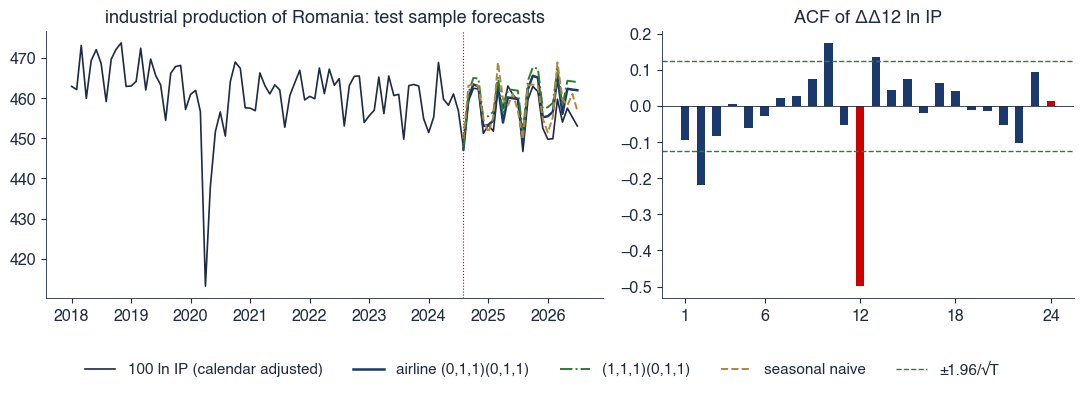

         adf     adf_p      kpss kpss_cv5
y  -1.311622  0.885025  0.523038    0.146
d1  -4.94589  0.000028  0.408661    0.463
z  -6.474299       0.0  0.054516    0.463
{'airline': {'model': '(0,1,1)(0,1,1)', 'aicc': 1304.183, 'bic': 1314.281, 'rmse': 3.753, 'mae': 2.945}, 'alt': {'model': '(1,1,1)(0,1,1)', 'aicc': 1291.064, 'bic': 1304.49, 'rmse': 5.288, 'mae': 4.478}}
seasonal naive: {'rmse': 3.8524106107758613, 'mae': 3.1788839229914125}


In [13]:
# Solution
b1 = b1_ip(save_it=False)
print(pd.DataFrame(b1['tests']).T[['adf', 'adf_p', 'kpss', 'kpss_cv5']].round(3))
print({k: {kk: (round(vv, 3) if isinstance(vv, float) else vv) for kk, vv in v.items() if kk in ('model', 'aicc', 'bic', 'rmse', 'mae')} for k, v in b1['models'].items()})
print('seasonal naive:', b1['sn'])

**Interpretation of the result.** The SARIMA$(1,1,1)(0,1,1)_{12}$ model wins in sample (lower BIC, clean residuals) but loses on the test sample; the airline model is slightly better than the seasonal naive method. Use the airline model and keep the seasonal naive method as the benchmark.

## B2 [Proposed]: volatility of the BET since 2015

**Question.** Is the Bucharest market calmer or more turbulent today than usual, and what does it mean for tomorrow's VaR 1%? Model: Seminar 5, B1.

1. Run the ARCH-LM test with five lags on the demeaned returns.
2. Fit a GARCH(1,1) with Student-t innovations; report the persistence and the half-life.
3. Compare the long-run, the sample and today's annualised volatility.
4. Compute tomorrow's VaR 1% with the t and with the Normal quantile.
5. Interpretation: is the BET calmer or more turbulent than usual today?

**Report:** one test, five parameters, three volatilities, two VaR values and one sentence.

In [ ]:
# Your code here


## B3 [Proposed]: the Romanian and German 10-year yields

**Question.** Is the Romanian 10-year yield tied to the German one in the long run? Model: Seminar 7, B1 and A3.

1. Run ADF on both yields and on their differences.
2. Run the Engle–Granger test (Romania on Germany) and report $\hat\beta$.
3. Run the Johansen trace and maximum-eigenvalue tests.
4. Estimate the error-correction equation of each yield and compute the half-life.
5. Interpretation: is the Romanian yield tied to the German one?

**Report:** four ADF results, two cointegration tests, two adjustment coefficients and one sentence.

In [ ]:
# Your code here


# Part C: an open idea and AI critique

## C1 [Proposed]: a forecast competition for Romanian inflation

**Question.** Which method would have forecast Romanian monthly inflation best over the last ten years, one and twelve months ahead?

1. List five competitors: seasonal naive, SES, SARIMA, ARFIMA, a ridge model with lags and month dummies.
2. Describe a rolling-origin design: first origin, step, horizons, refits.
3. Say how you would treat the tax changes of 2010, 2015 and 2025.
4. Choose the error measures and the test for the comparison.

**Report:** a one-page plan that a team could turn into its project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant checked the answers to Part A:

- (a) for the unemployment rate, ADF gives p = 0.52, so the unit root is rejected at 5%;
- (b) KPSS = 1.04 > 0.463 rejects, so the level of unemployment is stationary;
- (c) for the DAX, alpha + beta = 0.992, so a shock halves in 1/(1 - 0.992) days;
- (d) the VaR 99% of the DAX for tomorrow is negative;
- (e) inflation Granger-causes ROBOR, which proves that inflation causes the central bank to raise rates;
- (f) Ljung-Box Q(12) on the residuals of an AR(1) x SAR(1) model has 12 degrees of freedom.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
